In [19]:
import os
import csv
import time
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    TrainerCallback
)

from sklearn.metrics import f1_score
from scipy.stats import pearsonr

In [20]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print("\nLoading BRIGHTER dataset from Hugging Face...")

train_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="train")
val_data   = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="dev")
test_data  = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="test")

train_df = train_data.to_pandas()
val_df   = val_data.to_pandas()
test_df  = test_data.to_pandas()

print("\nOriginal split sizes:")
print("Train:", len(train_df))
print("Dev  :", len(val_df))
print("Test :", len(test_df))

print("\nSample data:")
print(train_df.head())


Loading BRIGHTER dataset from Hugging Face...

Original split sizes:
Train: 2763
Dev  : 115
Test : 2765

Sample data:
                        id                                               text  \
0  eng_train_track_b_00001                       Colorado, middle of nowhere.   
1  eng_train_track_b_00002  This involved swimming a pretty large lake tha...   
2  eng_train_track_b_00003        It was one of my most shameful experiences.   
3  eng_train_track_b_00004  After all, I had vegetables coming out my ears...   
4  eng_train_track_b_00005                        Then the screaming started.   

   anger  disgust  fear  joy  sadness  surprise  
0      0      NaN     1    0        0         1  
1      0      NaN     2    0        0         0  
2      0      NaN     1    0        3         0  
3      0      NaN     0    0        0         0  
4      0      NaN     3    0        1         2  


In [21]:
EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]
LEVELS = [1, 2, 3]
LABELS = [f"{emotion}_{level}" for emotion in EMOTIONS for level in LEVELS]
NUM_LABELS = len(LABELS)

print("Labels:")
print(LABELS)
print("Number of labels:", NUM_LABELS)

Labels:
['anger_1', 'anger_2', 'anger_3', 'fear_1', 'fear_2', 'fear_3', 'joy_1', 'joy_2', 'joy_3', 'sadness_1', 'sadness_2', 'sadness_3', 'surprise_1', 'surprise_2', 'surprise_3']
Number of labels: 15


In [22]:
def convert_single_step_labels(df):
    df = df.copy()

    # Remove disgust
    if "disgust" in df.columns:
        df = df.drop(columns=["disgust"])

    # Create 15 binary labels
    for emotion in EMOTIONS:
        df[f"{emotion}_1"] = (df[emotion] == 1).astype(int)
        df[f"{emotion}_2"] = (df[emotion] == 2).astype(int)
        df[f"{emotion}_3"] = (df[emotion] == 3).astype(int)

    return df

train_single = convert_single_step_labels(train_df)
val_single   = convert_single_step_labels(val_df)
test_single  = convert_single_step_labels(test_df)

print("\nSingle-step sample:")
print(train_single[["text"] + LABELS].head())


Single-step sample:
                                                text  anger_1  anger_2  \
0                       Colorado, middle of nowhere.        0        0   
1  This involved swimming a pretty large lake tha...        0        0   
2        It was one of my most shameful experiences.        0        0   
3  After all, I had vegetables coming out my ears...        0        0   
4                        Then the screaming started.        0        0   

   anger_3  fear_1  fear_2  fear_3  joy_1  joy_2  joy_3  sadness_1  sadness_2  \
0        0       1       0       0      0      0      0          0          0   
1        0       0       1       0      0      0      0          0          0   
2        0       1       0       0      0      0      0          0          0   
3        0       0       0       0      0      0      0          0          0   
4        0       0       0       1      0      0      0          1          0   

   sadness_3  surprise_1  surprise_2  surprise_

In [26]:
full_df = pd.concat([train_single, val_single, test_single], ignore_index=True)
full_df = full_df[["text"] + LABELS]
full_df = full_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

n = len(full_df)
train_end = int(0.7 * n)
val_end = int(0.9 * n)

train_single = full_df[:train_end]
val_single = full_df[train_end:val_end]
test_single = full_df[val_end:]

print({
    "train": len(train_single),
    "val": len(val_single),
    "test": len(test_single)
})

# Convert pandas DataFrames to Hugging Face Dataset
train_single = Dataset.from_pandas(train_single, preserve_index=False)
val_single   = Dataset.from_pandas(val_single, preserve_index=False)
test_single  = Dataset.from_pandas(test_single, preserve_index=False)

{'train': 3950, 'val': 1128, 'test': 565}


In [27]:
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

train_single = train_single.map(tokenize_function)
val_single   = val_single.map(tokenize_function)
test_single  = test_single.map(tokenize_function)

def add_labels(example):
    example["labels"] = [float(example[label]) for label in LABELS]
    return example

train_single = train_single.map(add_labels)
val_single   = val_single.map(add_labels)
test_single  = test_single.map(add_labels)

train_single.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_single.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_single.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/3950 [00:00<?, ? examples/s]

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

Map:   0%|          | 0/3950 [00:00<?, ? examples/s]

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

In [28]:

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    f1_macro = f1_score(labels, preds, average="macro", zero_division=0)
    f1_micro = f1_score(labels, preds, average="micro", zero_division=0)

    pearsons = []
    for i in range(labels.shape[1]):
        if np.std(labels[:, i]) == 0 or np.std(probs[:, i]) == 0:
            pearsons.append(0.0)
        else:
            p, _ = pearsonr(labels[:, i], probs[:, i])
            pearsons.append(0.0 if np.isnan(p) else float(p))

    pearson_mean = float(np.mean(pearsons))

    return {
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "pearson_mean": pearson_mean
    }

In [29]:
from google.colab import drive
drive.mount('/content/drive')

LOG_FILE = "/content/drive/MyDrive/RoBERTa_SingleStep_log.csv"
os.makedirs("/content/drive/MyDrive", exist_ok=True)

with open(LOG_FILE, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch",
        "train_loss",
        "eval_loss",
        "f1_macro",
        "f1_micro",
        "pearson_mean"
    ])

epoch_list = []
train_loss_list = []
eval_loss_list = []
f1_macro_list = []
pearson_mean_list = []

class SaveMetricsCallback(TrainerCallback):
    def __init__(self, file_path):
        self.file_path = file_path
        self.current_train_loss = None

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs and "eval_loss" not in logs:
            self.current_train_loss = float(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is not None:
            epoch = metrics.get("epoch", state.epoch)
            train_loss = self.current_train_loss if self.current_train_loss is not None else ""
            eval_loss = float(metrics.get("eval_loss", 0.0))
            f1_macro = float(metrics.get("eval_f1_macro", 0.0))
            f1_micro = float(metrics.get("eval_f1_micro", 0.0))
            pearson_mean = float(metrics.get("eval_pearson_mean", 0.0))

            epoch_list.append(epoch)
            train_loss_list.append(train_loss)
            eval_loss_list.append(eval_loss)
            f1_macro_list.append(f1_macro)
            pearson_mean_list.append(pearson_mean)

            with open(self.file_path, "a", newline="", encoding="utf-8") as f:
                writer = csv.writer(f)
                writer.writerow([
                    epoch,
                    train_loss,
                    eval_loss,
                    f1_macro,
                    f1_micro,
                    pearson_mean
                ])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)

training_args = TrainingArguments(
    output_dir="/content/roberta_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=4,
    num_train_epochs=10,   # you can change this to 3, 4, or 5
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_single,
    eval_dataset=val_single,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[SaveMetricsCallback(LOG_FILE)]
)

start = time.time()
trainer.train()
end = time.time()

print(f"Total training time: {end - start:.1f} seconds")
print("Epoch log file saved at:", LOG_FILE)

# =========================
# TEST EVALUATION
# =========================
test_results = trainer.evaluate(test_single)

print("\nTest Results:")
for key, value in test_results.items():
    print(f"{key}: {value}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,Pearson Mean
1,0.301342,0.253176,0.019340,0.052575,0.374951
2,0.237817,0.225083,0.151128,0.194129,0.460538
3,0.204580,0.220099,0.244208,0.331602,0.477379
4,0.175492,0.218295,0.320096,0.445561,0.484019
5,0.149450,0.223701,0.340306,0.456276,0.479686
6,0.128554,0.233237,0.372186,0.458996,0.472259
7,0.109962,0.240826,0.351230,0.452879,0.466100
8,0.096698,0.247768,0.376879,0.464408,0.465818
9,0.084781,0.251639,0.386366,0.469082,0.466593
10,0.078465,0.256275,0.388775,0.474833,0.462163


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Total training time: 567.3 seconds
Epoch log file saved at: /content/drive/MyDrive/RoBERTa_SingleStep_log.csv


NameError: name 'test_ds' is not defined

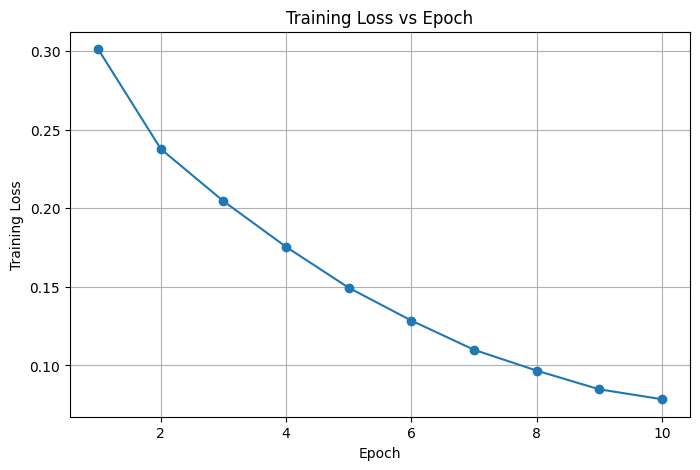

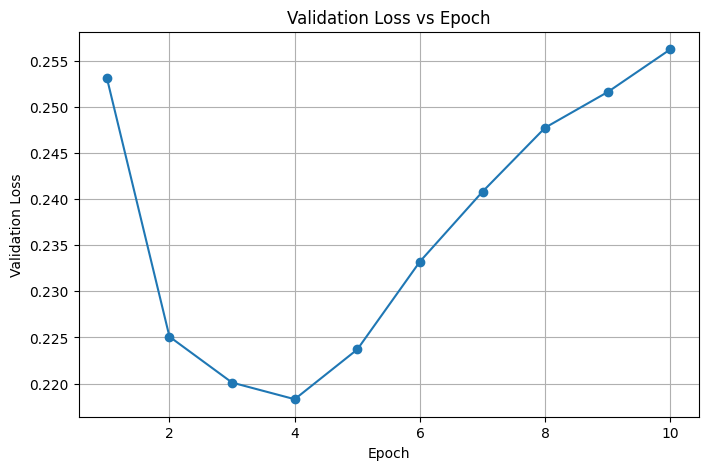

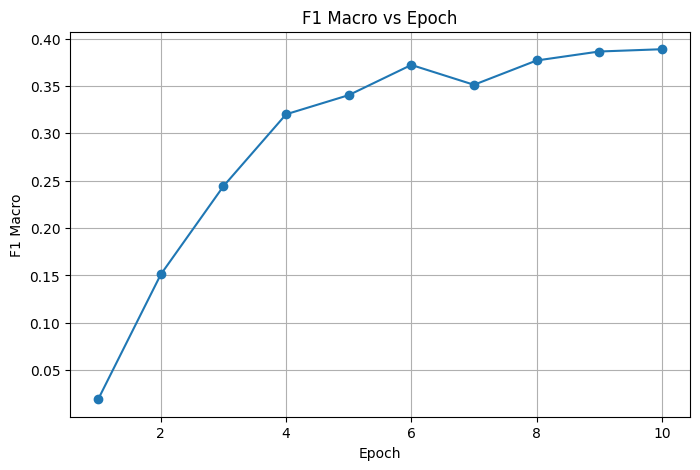

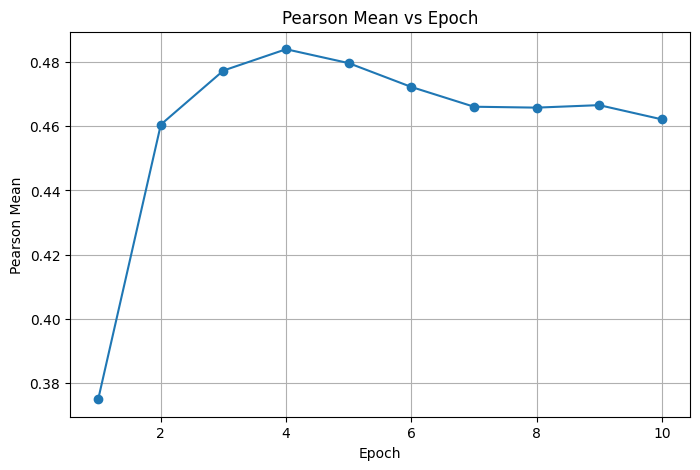

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, train_loss_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.show()

# Validation loss
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, eval_loss_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch")
plt.grid(True)
plt.show()

# F1 macro
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, f1_macro_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("F1 Macro")
plt.title("F1 Macro vs Epoch")
plt.grid(True)
plt.show()

# Pearson mean
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, pearson_mean_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Pearson Mean")
plt.title("Pearson Mean vs Epoch")
plt.grid(True)
plt.show()